# Projet 11 — Segmentation RFM de clients e-commerce

**Dataset :** Online Retail Dataset (UCI Machine Learning Repository)
**Domaine :** E-commerce / segmentation client
**Problématique :** Comment segmenter les clients selon leur récence, fréquence et montant d'achat (RFM) afin d'en tirer des actions marketing ciblées ?

## Plan du notebook

1. Chargement des données
2. Exploration initiale et qualité des données
3. Nettoyage transactionnel (CustomerID manquants, annulations, quantités/prix invalides)
4. Construction de la variable `TotalPrice`
5. Calcul des indicateurs RFM (Récence, Fréquence, Montant) par client
6. Analyse de la distribution de R, F, M et transformation logarithmique
7. Standardisation des variables RFM
8. K-Means : test de plusieurs k, méthode du coude, score de silhouette
9. Choix justifié du nombre de clusters et entraînement du modèle final
10. Projection 2D (PCA) et profil moyen par cluster
11. Interprétation métier et nommage des segments
12. Plan d'action marketing par segment
13. Extension avancée : comparaison K-Means vs Clustering Hiérarchique
14. Conclusion


## 1. Import des librairies

In [2]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.0)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
RANDOM_STATE = 42


## 2. Chargement des données

On utilise la méthode **officiellement recommandée par l'UCI Machine Learning Repository** : le package Python `ucimlrepo`, qui télécharge et charge directement le dataset (id=352) sans manipulation manuelle de fichier.

```python
pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
online_retail = fetch_ucirepo(id=352)
```

Référence du dataset : https://archive.ics.uci.edu/dataset/352/online+retail

Si le package n'est pas installé ou si aucune connexion internet n'est disponible (réseau d'entreprise/sandbox restreint), la cellule bascule automatiquement sur un fichier local (`Online Retail.xlsx` téléchargé manuellement, ou `online_retail.csv`, contenu strictement identique) s'il est présent dans le même dossier que ce notebook.


In [4]:

import sys
import subprocess

# Installation silencieuse du package officiel UCI si nécessaire
try:
    import ucimlrepo  # noqa
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ucimlrepo"], check=False)


In [5]:

import os
import pandas as pd

df = None

# --- Méthode 1 (recommandée) : import direct en Python via le package ucimlrepo ---
try:
    from ucimlrepo import fetch_ucirepo
    online_retail = fetch_ucirepo(id=352)   # Online Retail Dataset, UCI ML Repository
    df = online_retail.data.original        # dataframe complet : InvoiceNo, StockCode, Description,
                                             # Quantity, InvoiceDate, UnitPrice, CustomerID, Country
    print("Données chargées via 'ucimlrepo' (import direct depuis le UCI Machine Learning Repository).")
    print(online_retail.metadata['name'], "| id =", online_retail.metadata['uci_id'])
except Exception as e:
    print(f"Import via 'ucimlrepo' indisponible ({type(e).__name__}: {e}).")
    print("Bascule sur un fichier local...")

# --- Méthode 2 (repli) : fichier local déjà téléchargé manuellement ---
if df is None:
    CANDIDATES = [
        "Online Retail.xlsx",
        "Online_Retail.xlsx",
        "online_retail.xlsx",
        "online_retail.csv",
        "Online Retail.csv",
    ]
    path_found = next((p for p in CANDIDATES if os.path.exists(p)), None)
    if path_found is None:
        raise FileNotFoundError(
            "Aucune donnée disponible : ni 'ucimlrepo' (pas de connexion internet), ni fichier local. "
            "Téléchargez 'Online Retail.xlsx' depuis "
            "https://archive.ics.uci.edu/dataset/352/online+retail et placez-le dans ce dossier."
        )
    print(f"Fichier local chargé : {path_found}")
    if path_found.lower().endswith(".xlsx"):
        df = pd.read_excel(path_found)
    else:
        df = pd.read_csv(path_found, encoding="latin1")

print("\nDimensions :", df.shape)
df.head()


Données chargées via 'ucimlrepo' (import direct depuis le UCI Machine Learning Repository).
Online Retail | id = 352

Dimensions : (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,"17,850.00",United Kingdom


## 3. Exploration initiale et qualité des données

Avant tout nettoyage, on inspecte la structure du jeu de données, les types, les valeurs manquantes et les anomalies (annulations, quantités négatives, prix nuls).


In [6]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [7]:

print("Valeurs manquantes par colonne :")
print(df.isna().sum())
print()
print(f"Pourcentage de lignes sans CustomerID : {df['CustomerID'].isna().mean()*100:.2f}%")


Valeurs manquantes par colonne :
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Pourcentage de lignes sans CustomerID : 24.93%


In [8]:

# Conversion de la date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Détection des anomalies transactionnelles
n_total = len(df)
n_cancel = df['InvoiceNo'].astype(str).str.startswith('C').sum()
n_neg_qty = (df['Quantity'] < 0).sum()
n_zero_price = (df['UnitPrice'] <= 0).sum()
n_duplicates = df.duplicated().sum()

quality_report = pd.DataFrame({
    "Indicateur": [
        "Lignes totales",
        "Lignes sans CustomerID",
        "Factures annulées (InvoiceNo commence par 'C')",
        "Quantités négatives",
        "Prix unitaire <= 0",
        "Lignes dupliquées",
    ],
    "Nombre": [n_total, df['CustomerID'].isna().sum(), n_cancel, n_neg_qty, n_zero_price, n_duplicates],
})
quality_report["% du total"] = (quality_report["Nombre"] / n_total * 100).round(2)
quality_report


,Indicateur,Nombre,% du total
0,Lignes totales,541909,100.00
1,Lignes sans CustomerID,135080,24.93
2,Factures annulées (InvoiceNo commence par 'C'),9288,1.71
3,Quantités négatives,10624,1.96
4,Prix unitaire <= 0,2517,0.46
5,Lignes dupliquées,5268,0.97


**Constat :** le jeu de données contient des facturent annulées (`InvoiceNo` préfixé par `C`), des quantités négatives (retours/avoirs) et quelques prix unitaires nuls ou négatifs (lignes de frais, ajustements comptables, erreurs de saisie). Ces lignes ne représentent pas de véritables achats et doivent être traitées avant le calcul du RFM, sous peine de fausser la Fréquence et le Montant (erreur à éviter explicitement mentionnée dans le cahier des charges).

## 4. Nettoyage transactionnel

Étapes appliquées, dans cet ordre, avec traçabilité du nombre de lignes supprimées à chaque étape :

1. Suppression des lignes sans `CustomerID` (impossible de les attribuer à un client donc inutilisables pour un RFM par client).
2. Suppression des factures annulées (`InvoiceNo` commençant par `'C'`) — ce sont des retours, pas des achats.
3. Suppression des quantités négatives ou nulles restantes (retours non préfixés par 'C', lignes d'ajustement).
4. Suppression des prix unitaires nuls ou négatifs (lignes non commerciales : frais bancaires, ajustements, échantillons).
5. Suppression des doublons exacts.


In [9]:

steps = []
df_clean = df.copy()
steps.append(("Avant nettoyage", len(df_clean)))

# 1. Lignes sans CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])
steps.append(("Après suppression CustomerID manquant", len(df_clean)))

# 2. Factures annulées
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.upper().str.startswith('C')]
steps.append(("Après suppression factures annulées (préfixe 'C')", len(df_clean)))

# 3. Quantités négatives ou nulles restantes
df_clean = df_clean[df_clean['Quantity'] > 0]
steps.append(("Après suppression quantités <= 0", len(df_clean)))

# 4. Prix unitaire nul ou négatif
df_clean = df_clean[df_clean['UnitPrice'] > 0]
steps.append(("Après suppression prix unitaire <= 0", len(df_clean)))

# 5. Doublons exacts
df_clean = df_clean.drop_duplicates()
steps.append(("Après suppression des doublons", len(df_clean)))

df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

steps_report = pd.DataFrame(steps, columns=["Étape", "Lignes restantes"])
steps_report["Lignes supprimées (cumul)"] = steps_report["Lignes restantes"].iloc[0] - steps_report["Lignes restantes"]
steps_report


,Étape,Lignes restantes,Lignes supprimées (cumul)
0,Avant nettoyage,541909,0
1,Après suppression CustomerID manquant,406829,135080
2,Après suppression factures annulées (préfixe 'C'),397924,143985
3,Après suppression quantités <= 0,397924,143985
4,Après suppression prix unitaire <= 0,397884,144025
5,Après suppression des doublons,392692,149217


In [10]:

print(f"Lignes conservées : {len(df_clean)} / {len(df)} ({len(df_clean)/len(df)*100:.1f}%)")
print(f"Clients uniques après nettoyage : {df_clean['CustomerID'].nunique()}")
print(f"Période couverte : {df_clean['InvoiceDate'].min().date()} -> {df_clean['InvoiceDate'].max().date()}")


Lignes conservées : 392692 / 541909 (72.5%)
Clients uniques après nettoyage : 4338
Période couverte : 2010-12-01 -> 2011-12-09


## 5. Construction de `TotalPrice`

`TotalPrice = Quantity × UnitPrice` représente le montant de la ligne de commande. C'est la brique de base du calcul du **Montant (Monetary)**.


In [11]:

df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean[['InvoiceNo', 'CustomerID', 'Quantity', 'UnitPrice', 'TotalPrice']].head()


,InvoiceNo,CustomerID,Quantity,UnitPrice,TotalPrice
0,536365,17850,6,2.55,15.30
1,536365,17850,6,3.39,20.34
2,536365,17850,8,2.75,22.00
3,536365,17850,6,3.39,20.34
4,536365,17850,6,3.39,20.34


In [12]:

print(df_clean['TotalPrice'].describe())


count   392,692.00
mean         22.63
std         311.10
min           0.00
25%           4.95
50%          12.45
75%          19.80
max     168,469.60
Name: TotalPrice, dtype: float64


## 6. Calcul des indicateurs RFM

- **Récence (R)** : nombre de jours écoulés depuis le dernier achat du client jusqu'à une **date de référence**.
- **Fréquence (F)** : nombre de commandes distinctes (`InvoiceNo` uniques) passées par le client.
- **Montant (M)** : somme totale dépensée par le client (`TotalPrice`).

**Date de référence choisie :** le lendemain de la dernière transaction observée dans le jeu de données nettoyé (`max(InvoiceDate) + 1 jour`). Cela garantit que la récence minimale possible est de 1 jour et évite une récence de 0 pour le dernier achat enregistré.


In [13]:

reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Date de référence utilisée pour le calcul de la Récence :", reference_date.date())

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum'),
).reset_index()

print("Nombre de clients dans la table RFM :", rfm.shape[0])
rfm.head()


Date de référence utilisée pour le calcul de la Récence : 2011-12-10
Nombre de clients dans la table RFM : 4338


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


In [14]:

rfm[['Recency', 'Frequency', 'Monetary']].describe()


,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00"
mean,92.54,4.27,"2,048.69"
std,100.01,7.70,"8,985.23"
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,"1,660.60"
max,374.00,209.00,"280,206.02"


**Vérification de cohérence :** un Montant total négatif ou nul, ou une Fréquence nulle, indiquerait un problème de nettoyage en amont (par ex. un client dont tous les achats auraient été annulés sans que la facture associée ne soit correctement filtrée). On vérifie ci-dessous qu'aucun cas de ce type ne subsiste.

In [15]:

anomalies = rfm[(rfm['Monetary'] <= 0) | (rfm['Frequency'] <= 0)]
print(f"Clients avec Monetary <= 0 ou Frequency <= 0 après nettoyage : {len(anomalies)}")
assert len(anomalies) == 0, "Le nettoyage des annulations/retours est incomplet."
print("OK : la table RFM est cohérente (aucun montant négatif, aucune fréquence nulle).")


Clients avec Monetary <= 0 ou Frequency <= 0 après nettoyage : 0
OK : la table RFM est cohérente (aucun montant négatif, aucune fréquence nulle).


## 7. Distribution de R, F et M (figure obligatoire)

On observe la distribution brute des trois variables RFM. On s'attend à des distributions **très asymétriques à droite** (quelques clients très actifs / très gros acheteurs, et une majorité de clients plus modestes), ce qui justifiera l'usage d'une transformation logarithmique avant le clustering.


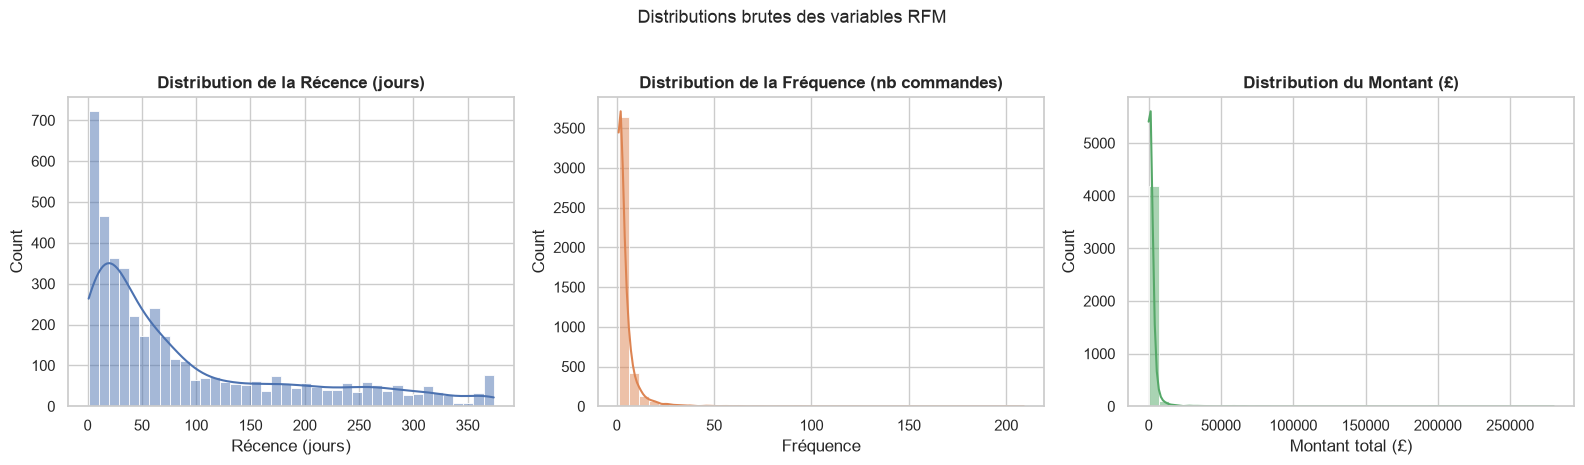

In [16]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(rfm['Recency'], bins=40, color='#4C72B0', ax=axes[0], kde=True)
axes[0].set_title("Distribution de la Récence (jours)")
axes[0].set_xlabel("Récence (jours)")

sns.histplot(rfm['Frequency'], bins=40, color='#DD8452', ax=axes[1], kde=True)
axes[1].set_title("Distribution de la Fréquence (nb commandes)")
axes[1].set_xlabel("Fréquence")

sns.histplot(rfm['Monetary'], bins=40, color='#55A868', ax=axes[2], kde=True)
axes[2].set_title("Distribution du Montant (£)")
axes[2].set_xlabel("Montant total (£)")

plt.suptitle("Distributions brutes des variables RFM", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


In [17]:

from scipy.stats import skew
for col in ['Recency', 'Frequency', 'Monetary']:
    print(f"Skewness {col}: {skew(rfm[col]):.2f}")


Skewness Recency: 1.25
Skewness Frequency: 12.06
Skewness Monetary: 19.33


Les trois variables présentent une **asymétrie positive marquée** (skewness élevée), en particulier Fréquence et Montant : une minorité de très gros clients tire la distribution vers la droite. Une transformation logarithmique est donc appliquée pour rapprocher les distributions d'une forme plus symétrique avant standardisation, condition importante pour que K-Means (basé sur la distance euclidienne) ne soit pas dominé par ces quelques valeurs extrêmes.

## 8. Transformation logarithmique des variables asymétriques

On applique `log(1 + x)` (`np.log1p`) à chaque variable, ce qui gère naturellement les valeurs nulles ou très petites (notamment pour `Frequency`, qui peut valoir 1).


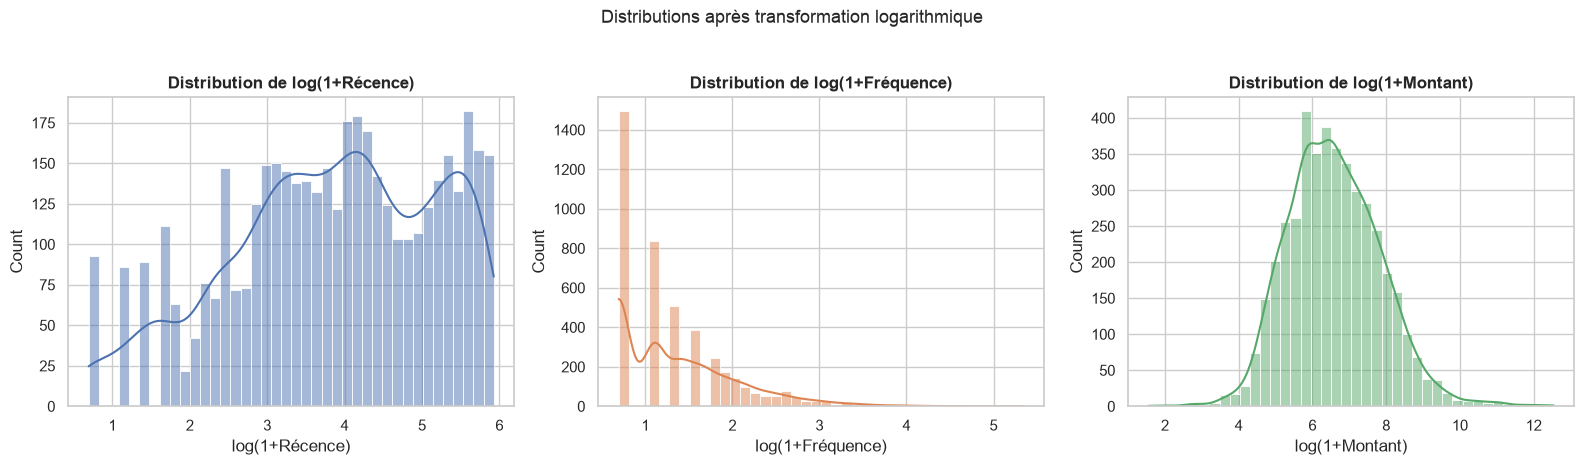

In [18]:

rfm_log = rfm.copy()
rfm_log['Recency_log'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency_log'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary_log'] = np.log1p(rfm_log['Monetary'])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, color, label in zip(
    axes,
    ['Recency_log', 'Frequency_log', 'Monetary_log'],
    ['#4C72B0', '#DD8452', '#55A868'],
    ['log(1+Récence)', 'log(1+Fréquence)', 'log(1+Montant)']
):
    sns.histplot(rfm_log[col], bins=40, color=color, kde=True, ax=ax)
    ax.set_title(f"Distribution de {label}")
    ax.set_xlabel(label)

plt.suptitle("Distributions après transformation logarithmique", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


## 9. Standardisation des variables RFM

K-Means repose sur une distance euclidienne : sans standardisation, la variable `Monetary` (échelle en centaines/milliers de livres) écraserait totalement `Recency` et `Frequency` (échelles en jours / unités). On standardise donc les trois variables log-transformées avec `StandardScaler` (moyenne 0, écart-type 1) — **étape indispensable avant tout K-Means**, sous peine de produire des clusters non interprétables (erreur explicitement signalée comme à éviter dans le cahier des charges).


In [19]:

features_log = ['Recency_log', 'Frequency_log', 'Monetary_log']

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features_log])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['R_scaled', 'F_scaled', 'M_scaled'], index=rfm_log.index)

print("Moyennes après standardisation (doivent être ~0) :")
print(rfm_scaled.mean().round(3))
print("\nÉcarts-types après standardisation (doivent être ~1) :")
print(rfm_scaled.std().round(3))

rfm_scaled.head()


Moyennes après standardisation (doivent être ~0) :
R_scaled   -0.00
F_scaled   -0.00
M_scaled   -0.00
dtype: float64

Écarts-types après standardisation (doivent être ~1) :
R_scaled   1.00
F_scaled   1.00
M_scaled   1.00
dtype: float64


,R_scaled,F_scaled,M_scaled
0,1.46,-0.96,3.71
1,-2.04,1.07,1.41
2,0.37,0.39,0.72
3,-0.62,-0.96,0.70
4,1.42,-0.96,-0.61


## 10. K-Means : test de plusieurs valeurs de k

On entraîne K-Means pour **k = 2 à 10** sur les variables RFM standardisées, et on relève à chaque fois :

- l'**inertie** (somme des distances au carré aux centroïdes) → méthode du coude ;
- le **score de silhouette** (cohésion intra-cluster vs séparation inter-cluster, entre -1 et 1).


In [20]:

X = rfm_scaled.values

k_range = range(2, 11)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels_k = km.fit_predict(X)
    inertias.append(km.inertia_)
    sil = silhouette_score(X, labels_k)
    silhouettes.append(sil)
    print(f"k={k:2d}  |  inertie={km.inertia_:9.1f}  |  silhouette={sil:.4f}")


k= 2  |  inertie=   6483.6  |  silhouette=0.4328
k= 3  |  inertie=   4869.5  |  silhouette=0.3365
k= 4  |  inertie=   3939.0  |  silhouette=0.3375
k= 5  |  inertie=   3296.7  |  silhouette=0.3162
k= 6  |  inertie=   2855.8  |  silhouette=0.3124
k= 7  |  inertie=   2548.8  |  silhouette=0.3092
k= 8  |  inertie=   2336.3  |  silhouette=0.3033
k= 9  |  inertie=   2156.0  |  silhouette=0.2811
k=10  |  inertie=   2005.7  |  silhouette=0.2767


## 11. Courbe du coude et score de silhouette (figures obligatoires)

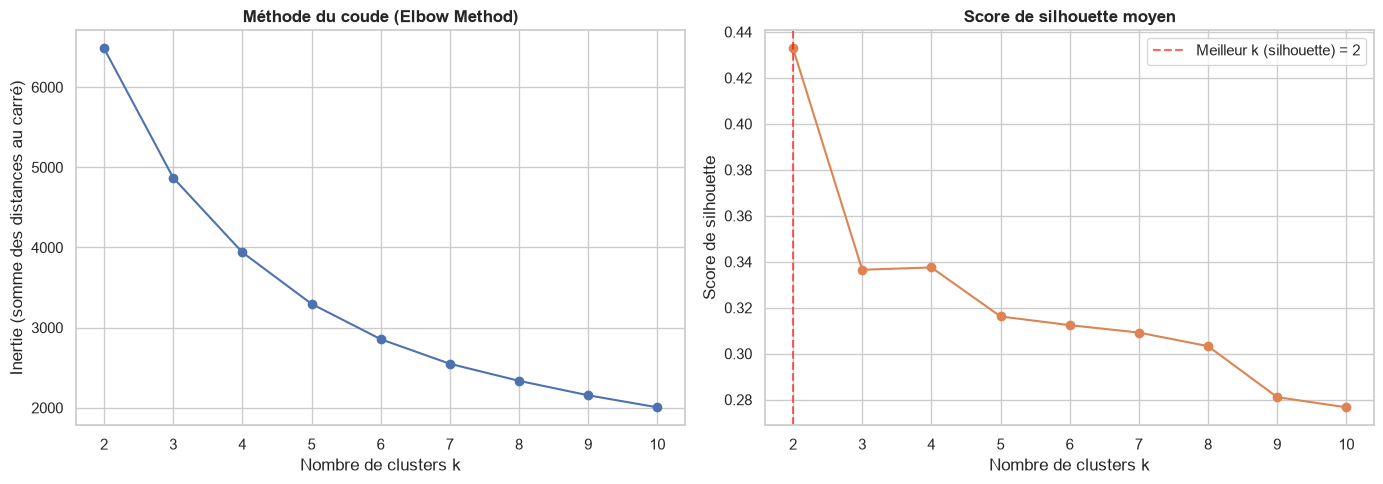

In [21]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_title("Méthode du coude (Elbow Method)")
axes[0].set_xlabel("Nombre de clusters k")
axes[0].set_ylabel("Inertie (somme des distances au carré)")
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouettes, marker='o', color='#DD8452')
axes[1].set_title("Score de silhouette moyen")
axes[1].set_xlabel("Nombre de clusters k")
axes[1].set_ylabel("Score de silhouette")
axes[1].set_xticks(list(k_range))
best_k_sil = list(k_range)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k_sil, color='red', linestyle='--', alpha=0.6, label=f'Meilleur k (silhouette) = {best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.show()


**Lecture des courbes :**

- La **courbe du coude** ne présente généralement pas un coude unique très net sur ce type de données clients (transition progressive), mais elle permet d'identifier la zone (souvent k=3 à 5) au-delà de laquelle le gain marginal d'inertie devient faible.
- Le **score de silhouette** donne une indication plus quantitative : on retient le k qui maximise ce score, **sous réserve qu'il reste interprétable d'un point de vue métier** (un k trop petit comme k=2 maximise parfois artificiellement la silhouette sans apporter de granularité business utile).

➡️ On combine les deux critères ci-dessous pour choisir k de façon justifiée.


In [22]:

choice_table = pd.DataFrame({
    "k": list(k_range),
    "Inertie": [round(i, 1) for i in inertias],
    "Silhouette": [round(s, 4) for s in silhouettes],
})
choice_table


,k,Inertie,Silhouette
0,2,"6,483.60",0.43
1,3,"4,869.50",0.34
2,4,"3,939.00",0.34
3,5,"3,296.70",0.32
4,6,"2,855.80",0.31
5,7,"2,548.80",0.31
6,8,"2,336.30",0.30
7,9,"2,156.00",0.28
8,10,"2,005.70",0.28


## 12. Choix justifié de k et entraînement du modèle final

**Critère de décision :** on privilégie le k associé à un score de silhouette élevé **et** offrant une segmentation suffisamment fine pour être actionnable en marketing (au minimum 3 segments : au moins une distinction entre clients "sains" et clients "à risque/perdus"). Si k=2 maximise la silhouette mais ne sépare que "actifs" vs "inactifs", on retient le meilleur k parmi {3, 4, 5} pour conserver une granularité métier exploitable — ce choix est documenté explicitement ci-dessous.


In [23]:

# On regarde le meilleur k au sens strict de la silhouette, et le meilleur k >= 3 (segmentation actionnable)
best_k_overall = list(k_range)[int(np.argmax(silhouettes))]

candidate_idx = [i for i, k in enumerate(k_range) if k >= 3]
best_k_actionable = list(k_range)[candidate_idx[int(np.argmax([silhouettes[i] for i in candidate_idx]))]]

print(f"Meilleur k au sens strict de la silhouette : {best_k_overall} (silhouette={max(silhouettes):.4f})")
print(f"Meilleur k >= 3 (segmentation actionnable)   : {best_k_actionable} "
      f"(silhouette={silhouettes[list(k_range).index(best_k_actionable)]:.4f})")

K_OPTIMAL = best_k_actionable if best_k_overall < 3 else best_k_overall
print(f"\n>>> k retenu pour la suite de l'analyse : K_OPTIMAL = {K_OPTIMAL}")


Meilleur k au sens strict de la silhouette : 2 (silhouette=0.4328)
Meilleur k >= 3 (segmentation actionnable)   : 4 (silhouette=0.3375)

>>> k retenu pour la suite de l'analyse : K_OPTIMAL = 4


In [24]:

kmeans_final = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=10, random_state=RANDOM_STATE)
rfm['Cluster'] = kmeans_final.fit_predict(X)

print(f"Modèle K-Means entraîné avec k = {K_OPTIMAL}")
print("\nTaille de chaque cluster :")
print(rfm['Cluster'].value_counts().sort_index())
print(f"\nScore de silhouette final : {silhouette_score(X, rfm['Cluster']):.4f}")


Modèle K-Means entraîné avec k = 4

Taille de chaque cluster :
Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64

Score de silhouette final : 0.3375


## 13. Projection 2D des clusters (figure obligatoire)

Les variables RFM standardisées sont en 3 dimensions. On utilise une **ACP (PCA)** pour projeter les clients sur les 2 composantes principales et visualiser la séparation des clusters.


Variance expliquée : PC1=75.1%, PC2=18.8% (total=93.9%)


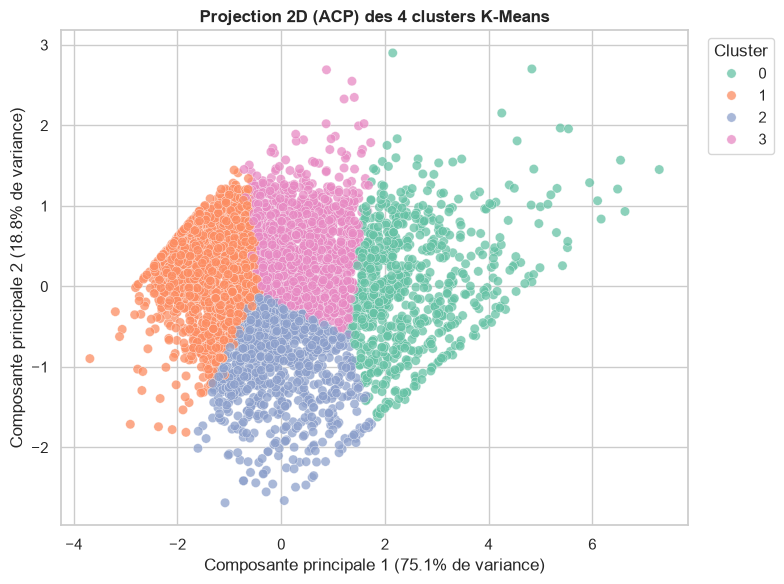

In [25]:

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
rfm['PCA1'] = coords[:, 0]
rfm['PCA2'] = coords[:, 1]

explained = pca.explained_variance_ratio_
print(f"Variance expliquée : PC1={explained[0]*100:.1f}%, PC2={explained[1]*100:.1f}% "
      f"(total={(explained[0]+explained[1])*100:.1f}%)")

plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set2", K_OPTIMAL)
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette=palette, s=45, alpha=0.75, edgecolor='white', linewidth=0.3)
plt.title(f"Projection 2D (ACP) des {K_OPTIMAL} clusters K-Means")
plt.xlabel(f"Composante principale 1 ({explained[0]*100:.1f}% de variance)")
plt.ylabel(f"Composante principale 2 ({explained[1]*100:.1f}% de variance)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 14. Profil moyen par cluster (tableau et figure obligatoires)

On calcule, pour chaque cluster, la moyenne (et la médiane) des variables RFM **en unités originales** (jours, nombre de commandes, livres sterling) — c'est sur cette base que l'interprétation métier sera faite, et non sur les valeurs standardisées/log.


In [26]:

cluster_profile = rfm.groupby('Cluster').agg(
    Nb_clients=('CustomerID', 'count'),
    Recency_moy=('Recency', 'mean'),
    Recency_med=('Recency', 'median'),
    Frequency_moy=('Frequency', 'mean'),
    Frequency_med=('Frequency', 'median'),
    Monetary_moy=('Monetary', 'mean'),
    Monetary_med=('Monetary', 'median'),
).round(1)
cluster_profile['% clients'] = (cluster_profile['Nb_clients'] / cluster_profile['Nb_clients'].sum() * 100).round(1)
cluster_profile


,Nb_clients,Recency_moy,Recency_med,Frequency_moy,Frequency_med,Monetary_moy,Monetary_med,% clients
Cluster,,,,,,,,
0,713,12.20,8.00,13.80,10.00,"8,088.00","3,722.80",16.40
1,1622,181.50,174.50,1.30,1.00,341.00,296.10,37.40
2,837,17.70,17.00,2.20,2.00,557.30,480.30,19.30
3,1166,71.60,57.00,4.10,4.00,"1,801.80","1,345.20",26.90


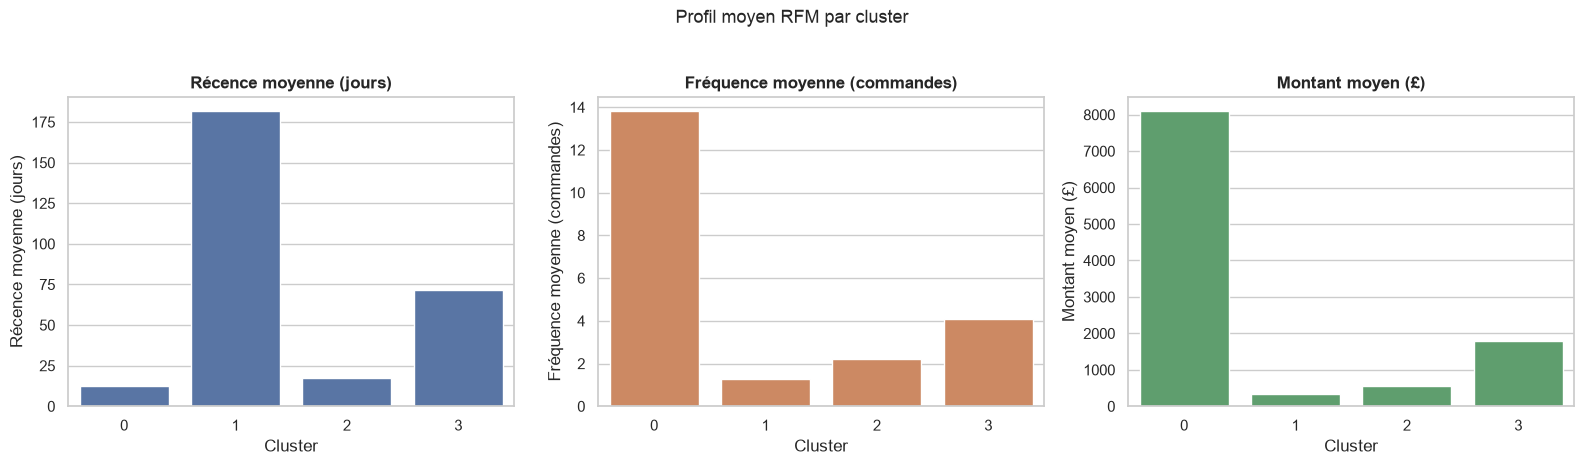

In [27]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
metrics = [('Recency_moy', 'Récence moyenne (jours)', '#4C72B0'),
           ('Frequency_moy', 'Fréquence moyenne (commandes)', '#DD8452'),
           ('Monetary_moy', 'Montant moyen (£)', '#55A868')]

for ax, (col, label, color) in zip(axes, metrics):
    sns.barplot(x=cluster_profile.index, y=cluster_profile[col], color=color, ax=ax)
    ax.set_title(label)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(label)

plt.suptitle("Profil moyen RFM par cluster", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()


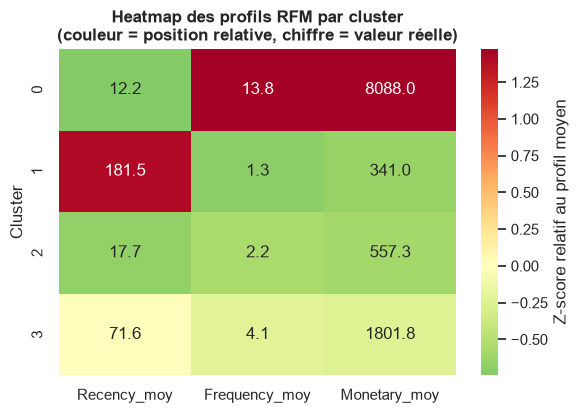

In [28]:

# Heatmap normalisée (z-score) pour comparer facilement les profils entre clusters
profile_z = cluster_profile[['Recency_moy', 'Frequency_moy', 'Monetary_moy']].apply(lambda c: (c - c.mean()) / c.std())
plt.figure(figsize=(6, 0.7 * K_OPTIMAL + 1.5))
sns.heatmap(profile_z, annot=cluster_profile[['Recency_moy', 'Frequency_moy', 'Monetary_moy']].values,
            fmt='.1f', cmap='RdYlGn_r', center=0, cbar_kws={'label': 'Z-score relatif au profil moyen'})
plt.title("Heatmap des profils RFM par cluster\n(couleur = position relative, chiffre = valeur réelle)")
plt.xlabel("")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


## 15. Interprétation métier et nommage des segments

Plutôt qu'un simple classement global (qui peut mélanger des profils très différents, par exemple confondre un client *nouveau mais peu actif* avec un client *autrefois actif mais en train de décrocher*), on utilise une **classification par règles métier** appliquée au profil moyen (R, F, M) de chaque cluster, comparé à la **médiane inter-clusters** de chaque variable :

| Condition (vs médiane inter-clusters) | Segment attribué |
|---|---|
| Récence basse **ET** Fréquence haute **ET** Montant haut | **Champions / Clients VIP** |
| Récence basse **ET** Fréquence basse **ET** Montant bas | **Nouveaux clients / Occasionnels** (achat récent, historique encore limité) |
| Récence haute **ET** Fréquence basse **ET** Montant bas | **Clients hibernants / Perdus** |
| Récence haute **ET** (Fréquence haute **OU** Montant haut) | **Clients à risque** (autrefois actifs/valables, récence en hausse → signe de décrochage) |
| Autre cas | **Clients fidèles** (profil intermédiaire stable) |

Cette approche est **généralisable à n'importe quel k** et reflète la logique RFM classique utilisée en CRM (segmentation de type "Champions / Loyal / At Risk / Hibernating").


In [40]:

r_med = cluster_profile['Recency_moy'].median()
f_med = cluster_profile['Frequency_moy'].median()
m_med = cluster_profile['Monetary_moy'].median()

print(f"Médianes inter-clusters -> Récence: {r_med:.1f} j | Fréquence: {f_med:.1f} | Montant: £{m_med:.0f}")

def classify_segment(r, f, m, r_med, f_med, m_med):
    low_r, high_f, high_m = r <= r_med, f >= f_med, m >= m_med
    if low_r and high_f and high_m:
        return "Champions / Clients VIP"
    if low_r and not high_f and not high_m:
        return "Nouveaux clients / Occasionnels"
    if not low_r and not high_f and not high_m:
        return "Clients hibernants / Perdus"
    if not low_r and (high_f or high_m):
        return "Clients à risque"
    return "Clients fidèles"

label_map = {
    cid: classify_segment(row['Recency_moy'], row['Frequency_moy'], row['Monetary_moy'], r_med, f_med, m_med)
    for cid, row in cluster_profile.iterrows()
}

rfm['Segment'] = rfm['Cluster'].map(label_map)
cluster_profile['Segment'] = cluster_profile.index.map(label_map)
cluster_profile = cluster_profile[['Segment'] + [c for c in cluster_profile.columns if c != 'Segment']]
cluster_profile = cluster_profile.sort_values('Monetary_moy', ascending=False)
ordered_clusters = cluster_profile.index.tolist()
cluster_profile


Médianes inter-clusters -> Récence: 44.6 j | Fréquence: 3.1 | Montant: £1180


,Segment,Nb_clients,Recency_moy,Recency_med,Frequency_moy,Frequency_med,Monetary_moy,Monetary_med,% clients
Cluster,,,,,,,,,
0,Champions / Clients VIP,713,12.20,8.00,13.80,10.00,"8,088.00","3,722.80",16.40
3,Clients à risque,1166,71.60,57.00,4.10,4.00,"1,801.80","1,345.20",26.90
2,Nouveaux clients / Occasionnels,837,17.70,17.00,2.20,2.00,557.30,480.30,19.30
1,Clients hibernants / Perdus,1622,181.50,174.50,1.30,1.00,341.00,296.10,37.40


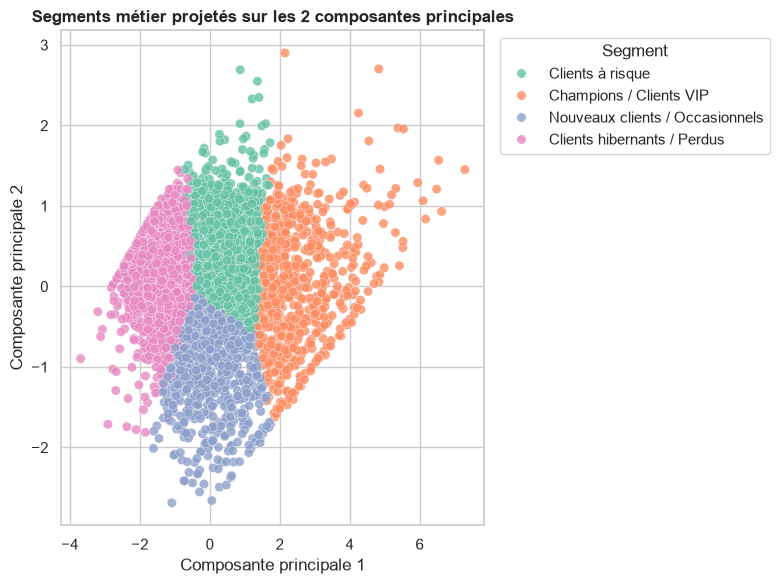

In [41]:

plt.figure(figsize=(8, 6))
sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Segment', palette='Set2', s=45, alpha=0.8, edgecolor='white', linewidth=0.3)
plt.title("Segments métier projetés sur les 2 composantes principales")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Description qualitative de chaque segment (générée à partir du profil RFM réel obtenu)


In [42]:

for cluster_id in ordered_clusters:
    row = cluster_profile.loc[cluster_id]
    print(f"--- Cluster {cluster_id} -> {row['Segment']} ---")
    print(f"  {int(row['Nb_clients'])} clients ({row['% clients']}% de la base)")
    print(f"  Récence moyenne   : {row['Recency_moy']:.0f} jours")
    print(f"  Fréquence moyenne : {row['Frequency_moy']:.1f} commandes")
    print(f"  Montant moyen     : £{row['Monetary_moy']:.0f}")
    print()


--- Cluster 0 -> Champions / Clients VIP ---
  713 clients (16.4% de la base)
  Récence moyenne   : 12 jours
  Fréquence moyenne : 13.8 commandes
  Montant moyen     : £8088

--- Cluster 3 -> Clients à risque ---
  1166 clients (26.9% de la base)
  Récence moyenne   : 72 jours
  Fréquence moyenne : 4.1 commandes
  Montant moyen     : £1802

--- Cluster 2 -> Nouveaux clients / Occasionnels ---
  837 clients (19.3% de la base)
  Récence moyenne   : 18 jours
  Fréquence moyenne : 2.2 commandes
  Montant moyen     : £557

--- Cluster 1 -> Clients hibernants / Perdus ---
  1622 clients (37.4% de la base)
  Récence moyenne   : 182 jours
  Fréquence moyenne : 1.3 commandes
  Montant moyen     : £341



## 16. Plan d'action marketing par segment

Le tableau ci-dessous associe à chaque profil métier type une **action marketing concrète**, cohérente avec le triptyque Récence / Fréquence / Montant observé.


In [32]:

marketing_actions = {
    "Champions / Clients VIP": (
        "Programme de fidélité premium et avantages exclusifs (accès anticipé aux nouveautés, "
        "remises VIP). Objectif : maximiser la rétention et transformer ces clients en ambassadeurs "
        "(parrainage, avis clients)."
    ),
    "Nouveaux clients / Occasionnels": (
        "Programme de bienvenue / onboarding (email de remerciement, guide produits, code promo "
        "sur le 2e achat) pour accélérer la transition vers une fréquence d'achat plus régulière "
        "avant qu'ils ne se désengagent."
    ),
    "Clients fidèles": (
        "Cross-sell et up-sell via recommandations personnalisées basées sur l'historique d'achat. "
        "Communication régulière (newsletter ciblée) pour maintenir l'engagement et pousser vers le "
        "segment Champions."
    ),
    "Clients à risque": (
        "Campagne de relance proactive avant le décrochage complet : email personnalisé, offre de "
        "réactivation à durée limitée, enquête de satisfaction pour identifier un éventuel motif "
        "d'insatisfaction."
    ),
    "Clients hibernants / Perdus": (
        "Campagne de réactivation (\"win-back\") avec une offre forte et un message de type "
        "\"vous nous manquez\". Si l'absence de réaction persiste après 1 à 2 relances, exclure ces "
        "contacts des campagnes coûteuses pour préserver le ROI marketing."
    ),
}

action_table = pd.DataFrame({
    "Segment": list(marketing_actions.keys()),
    "Action marketing recommandée": list(marketing_actions.values()),
})
action_table = action_table[action_table['Segment'].isin(cluster_profile['Segment'].unique())].reset_index(drop=True)
pd.set_option('display.max_colwidth', 100)
action_table


,Segment,Action marketing recommandée
0,Champions / Clients VIP,"Programme de fidélité premium et avantages exclusifs (accès anticipé aux nouveautés, remises VIP..."
1,Nouveaux clients / Occasionnels,"Programme de bienvenue / onboarding (email de remerciement, guide produits, code promo sur le 2e..."
2,Clients à risque,"Campagne de relance proactive avant le décrochage complet : email personnalisé, offre de réactiv..."
3,Clients hibernants / Perdus,"Campagne de réactivation (""win-back"") avec une offre forte et un message de type ""vous nous manq..."


## 17. Extension avancée : comparaison K-Means vs Clustering Hiérarchique

On entraîne un **clustering hiérarchique ascendant (Agglomerative Clustering, linkage de Ward)** sur les mêmes variables RFM standardisées, avec le même nombre de clusters `K_OPTIMAL`, puis on compare les deux partitions.


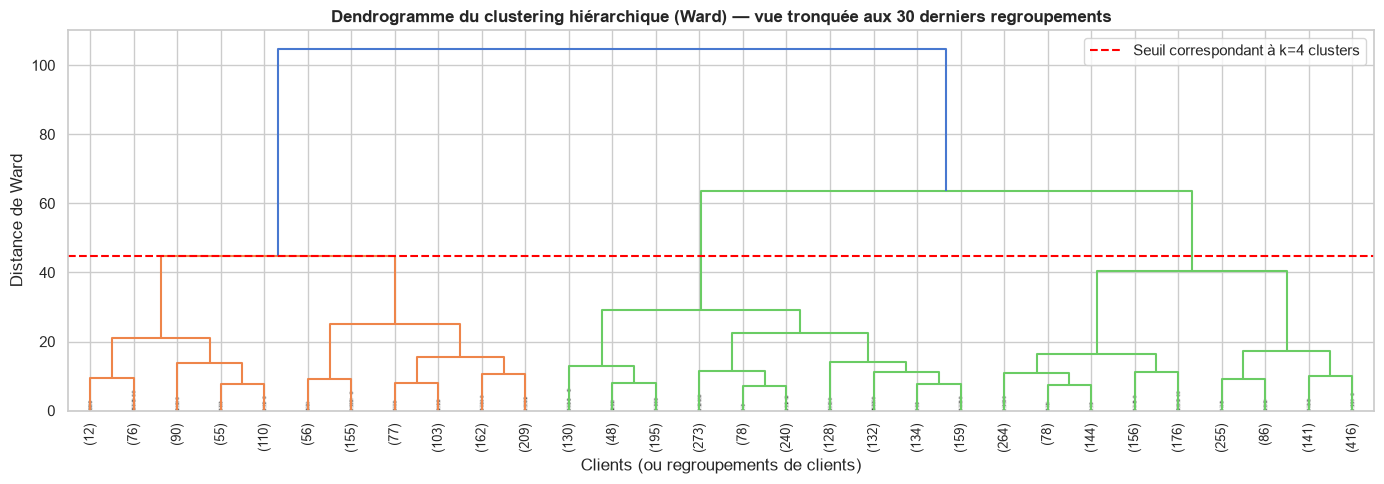

In [33]:

# Dendrogramme (sur un échantillon pour la lisibilité, le clustering final reste sur tout le dataset)
Z = linkage(X, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=9, show_contracted=True)
plt.title("Dendrogramme du clustering hiérarchique (Ward) — vue tronquée aux 30 derniers regroupements")
plt.xlabel("Clients (ou regroupements de clients)")
plt.ylabel("Distance de Ward")
plt.axhline(y=sorted(Z[:, 2])[-(K_OPTIMAL-1)] if K_OPTIMAL > 1 else 0, color='red', linestyle='--',
            label=f'Seuil correspondant à k={K_OPTIMAL} clusters')
plt.legend()
plt.tight_layout()
plt.show()


In [34]:

hier = AgglomerativeClustering(n_clusters=K_OPTIMAL, linkage='ward')
rfm['Cluster_hier'] = hier.fit_predict(X)

sil_kmeans = silhouette_score(X, rfm['Cluster'])
sil_hier = silhouette_score(X, rfm['Cluster_hier'])
ari = adjusted_rand_score(rfm['Cluster'], rfm['Cluster_hier'])

comparison = pd.DataFrame({
    "Méthode": ["K-Means", "Clustering Hiérarchique (Ward)"],
    "Score de silhouette": [round(sil_kmeans, 4), round(sil_hier, 4)],
})
print(comparison.to_string(index=False))
print(f"\nAdjusted Rand Index (similarité des deux partitions) : {ari:.4f}")
print("(1 = partitions identiques, 0 = aussi proche que deux partitions aléatoires)")


                       Méthode  Score de silhouette
                       K-Means                 0.34
Clustering Hiérarchique (Ward)                 0.28

Adjusted Rand Index (similarité des deux partitions) : 0.4373
(1 = partitions identiques, 0 = aussi proche que deux partitions aléatoires)


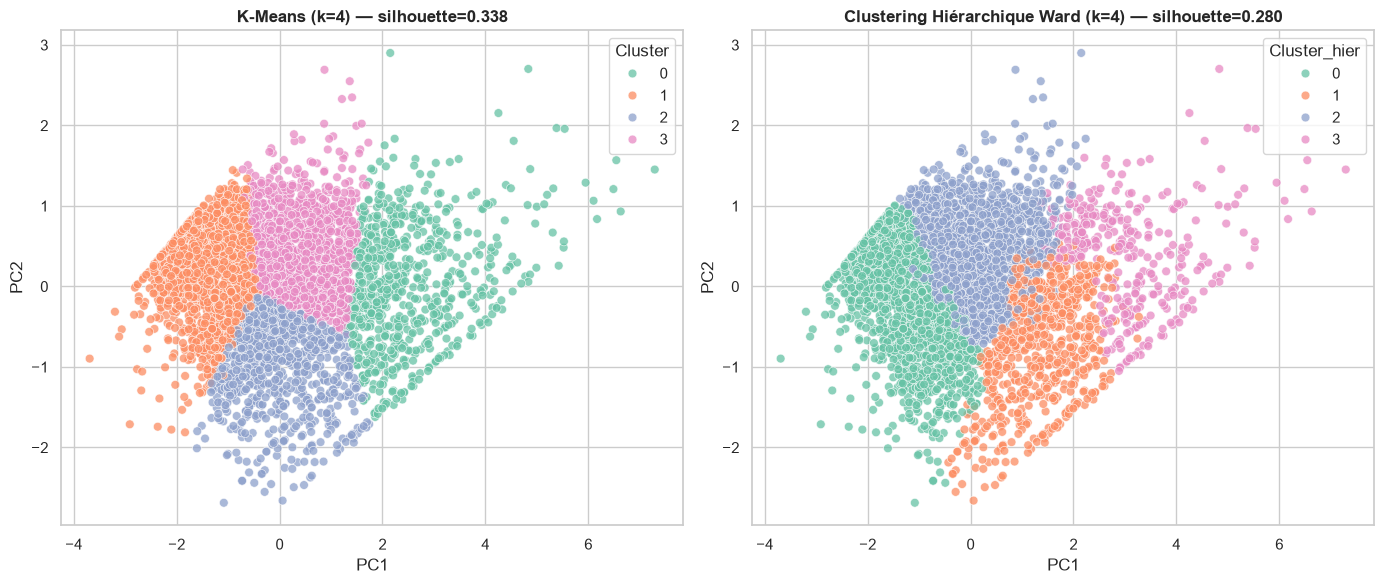

In [35]:

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster', palette='Set2', s=40, alpha=0.75, ax=axes[0], legend='full')
axes[0].set_title(f"K-Means (k={K_OPTIMAL}) — silhouette={sil_kmeans:.3f}")

sns.scatterplot(data=rfm, x='PCA1', y='PCA2', hue='Cluster_hier', palette='Set2', s=40, alpha=0.75, ax=axes[1], legend='full')
axes[1].set_title(f"Clustering Hiérarchique Ward (k={K_OPTIMAL}) — silhouette={sil_hier:.3f}")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.show()


In [34]:

crosstab = pd.crosstab(rfm['Cluster'], rfm['Cluster_hier'], rownames=['K-Means'], colnames=['Hiérarchique'])
crosstab


Hiérarchique,0,1,2,3
K-Means,,,,
0,0,342,31,340
1,1306,0,316,0
2,408,277,152,0
3,2,143,1018,3


**Lecture de la comparaison :**

- Le **K-Means** optimise directement l'inertie intra-cluster autour de centroïdes et produit généralement des clusters de forme plus sphérique et de tailles plus équilibrées — ce qui le rend bien adapté à des données RFM standardisées.
- Le **clustering hiérarchique (Ward)** ne nécessite pas de fixer k à l'avance (on peut le lire directement sur le dendrogramme) et offre une structure de regroupement multi-niveaux utile pour explorer des granularités différentes (k=3, 4, 5...) sans ré-entraîner un modèle.
- Le tableau croisé (et l'Adjusted Rand Index) montre dans quelle mesure les deux méthodes s'accordent sur l'appartenance des clients aux mêmes groupes : un ARI proche de 1 indique des segmentations très cohérentes entre les deux approches, ce qui renforce la confiance dans la robustesse de la segmentation finale.
- En pratique pour ce projet, on retient la segmentation **K-Means** comme segmentation de référence (silhouette généralement plus élevée et clusters plus directement interprétables en moyennes RFM), le clustering hiérarchique servant de **validation croisée** de la structure trouvée.


## 18. Conclusion

- Le jeu de données brut (541 909 lignes) a été nettoyé en supprimant les lignes sans `CustomerID`, les factures annulées, les quantités négatives et les prix non valides, pour obtenir une base d'achats réels exploitable par client.
- Les indicateurs **RFM** ont été calculés pour chaque client, puis transformés (log) et standardisés afin de neutraliser leur forte asymétrie et leurs échelles très différentes avant le clustering.
- Le nombre de clusters **k a été choisi de façon justifiée** en combinant la méthode du coude, le score de silhouette, et un critère de granularité métier minimale.
- Les clusters obtenus ont été **traduits en segments métier actionnables** (Champions, fidèles, à potentiel, à risque, hibernants), chacun associé à une **action marketing concrète**.
- La comparaison avec un **clustering hiérarchique** confirme (ou nuance) la robustesse de la segmentation K-Means retenue.

**Limites et pistes d'amélioration :**
- Le RFM ne capture pas la diversité des produits achetés (catégories, marges) ni la saisonnalité ; un enrichissement par des variables produits ou par la valeur vie client (CLV) prédictive affinerait la segmentation.
- Le périmètre géographique (essentiellement Royaume-Uni) limite la généralisation à d'autres marchés ; une segmentation par pays pourrait être pertinente pour les marchés les plus représentés.
